In [19]:
from ccka.models.kernel import KernelModel
from ccka.circuits.angleEmbeddingKernel import quackEmbeddingCircuit
from ccka.aligner.kta import fullKTA, centroidBasedKTA, quackKTA, randomKTA, greedyKTA
import pennylane as qml
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib as mpl
import time
import os
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [20]:
def load_data(dataset_path):
    data = jnp.load(dataset_path, allow_pickle=True).item()
    X = jnp.asarray(data['x_train'])
    y = jnp.asarray(data['y_train'])
    #x_test = jnp.asarray(data['x_test'])
    #y_test = jnp.asarray(data['y_test'])

    #X_combined = jnp.concatenate([X, x_test], axis=0)
    #y_combined = jnp.concatenate([y, y_test], axis=0)

    return X, y

X, y = load_data('../data/checkerboard_dataset.npy')
X.shape

(30, 2)

In [21]:
def run_experiment(
    method,
    dataset,
    dataset_path,
    centroids,
    num_iterations,
    noise_type,
    noise_level,
    run_id=None,
    seed=None
):

    X, y = load_data(dataset_path)

    kernel = quackEmbeddingCircuit(
        num_qubits=5,
        reps=6,
        reupload=True,
        noisy=True,
        noise_type=noise_type,
        noise_level=noise_level,
        seed = seed,
    )

    init_weights = kernel.init_weights()

    model = KernelModel(
        circuit=kernel,
        device_name='default.mixed',
        diff_method=None,
    )

    # ---------------------------------------------------------------
    # Full KTA
    # ---------------------------------------------------------------
    if method == 'fullKTA':

        aligner = fullKTA(
            kernel_model=model,
            data=X,
            labels=y,
            matrix_type='regular',
            split_size=0.50,
            learning_rate=0.1,
            optimizer='adam',
            epochs=num_iterations,
            seed = seed,
        )

    # ---------------------------------------------------------------
    # Centroid KTA
    # ---------------------------------------------------------------
    elif method == 'centroidBasedKTA':
        aligner = centroidBasedKTA(
            kernel_model=model,
            data=X,
            labels=y,
            matrix_type='regular',
            clustering='regular',
            split_size=0.50,
            centroids=centroids,
            lambda_co=0.001,
            lambda_kao=0.001,
            epochs=num_iterations,
            eps=0.001,
            alpha=0.01,
            seed = seed,
        )

    # ---------------------------------------------------------------
    # Greedy KTA
    # ---------------------------------------------------------------
    elif method == 'greedyKTA':

        aligner = greedyKTA(
            kernel_model=model,
            data=X,
            labels=y,
            matrix_type='regular',
            split_size=0.50,
            greedy_samples=centroids,
            landmark_points=10,
            learning_rate=0.1,
            optimizer='adam',
            epochs=num_iterations,
            seed = seed,
        )

    # ---------------------------------------------------------------
    # Random KTA
    # ---------------------------------------------------------------
    elif method == 'randomKTA':

        aligner = randomKTA(
            kernel_model=model,
            data=X,
            labels=y,
            matrix_type='regular',
            split_size=0.50,
            random_samples=centroids,
            landmark_points=10,
            learning_rate=0.1,
            optimizer='adam',
            epochs=num_iterations,
            seed = seed,
        )

    # ---------------------------------------------------------------
    # QUACK KTA
    # ---------------------------------------------------------------
    elif method == 'quackKTA':

        aligner = quackKTA(
            kernel_model=model,
            data=X,
            labels=y,
            matrix_type='regular',
            clustering='regular',
            split_size=0.50,
            centroids=centroids,
            lambda_co=0.001,
            lambda_kao=0.001,
            epochs=num_iterations,
            eps=0.001,
            alpha=0.01,
            seed = seed,
        )

    else:
        raise ValueError(
            f"Unknown method: {method}"
        )

    # ---------------------------------------------------------------
    # Run alignment
    # ---------------------------------------------------------------
    history = aligner.align()

    # Your existing bookkeeping
    if method == 'centroidBasedKTA':
        num_iterations = num_iterations * 10

    final_accuracy = history['test_accuracy_history'][-1]

    return final_accuracy

In [22]:
# ── global matplotlib style (publication-ready) ───────────────────────────
mpl.rcParams.update({
    'font.family':           'serif',
    'font.serif':            ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset':      'stix',
    'axes.labelsize':        10,
    'axes.titlesize':        10,
    'xtick.labelsize':       9,
    'ytick.labelsize':       9,
    'legend.fontsize':       8,
    'legend.title_fontsize': 8,
    'figure.dpi':            300,
    'savefig.dpi':           300,
    'axes.linewidth':        0.8,
    'xtick.major.width':     0.8,
    'ytick.major.width':     0.8,
    'xtick.minor.width':     0.5,
    'ytick.minor.width':     0.5,
    'lines.linewidth':       1.6,
    'patch.linewidth':       0.6,
})

# ── publication color palette (colorblind-safe, print-safe) ───────────────
# Based on Paul Tol's colorblind-safe palette
METHOD_STYLES = {
    'fullKTA': {
        'color':     '#0077BB',    # blue
        'marker':    'o',
        'linestyle': '-',
        'bar_color': '#0077BB',
        'hatch':     '',
    },
    'centroidBasedKTA': {
        'color':     '#EE7733',    # orange
        'marker':    's',
        'linestyle': '--',
        'bar_color': '#EE7733',
        'hatch':     '//',
    },
    'randomKTA': {
        'color':     '#009988',    # teal
        'marker':    '^',
        'linestyle': '-.',
        'bar_color': '#009988',
        'hatch':     'xx',
    },
    'greedyKTA': {
        'color':     '#CC3311',    # vermillion
        'marker':    'D',
        'linestyle': ':',
        'bar_color': '#CC3311',
        'hatch':     '\\\\',
    },
    'quackKTA': {
        'color':     '#AA3377',    # magenta/purple
        'marker':    'v',
        'linestyle': (0, (3, 1, 1, 1)),   # densely dash-dotted
        'bar_color': '#AA3377',
        'hatch':     '..',
    },
}

# Fallback styles for unexpected extra methods
_EXTRA_STYLES = [
    {'color': '#009988', 'marker': '^', 'linestyle': '-.', 'bar_color': '#009988', 'hatch': 'xx'},
    {'color': '#CC3311', 'marker': 'D', 'linestyle': ':',  'bar_color': '#CC3311', 'hatch': '\\\\'},
    {'color': '#AA3377', 'marker': 'v', 'linestyle': '-',  'bar_color': '#AA3377', 'hatch': '..'},
]

INITIAL_BAR_COLOR = '#4477AA'   # darker blue  — "Initial"
FINAL_BAR_COLOR   = '#EE6677'   # muted red    — "Final"


def _get_style(method, methods):
    if method in METHOD_STYLES:
        return METHOD_STYLES[method]
    idx = [m for m in methods if m not in METHOD_STYLES].index(method)
    return _EXTRA_STYLES[idx % len(_EXTRA_STYLES)]


In [23]:
from tqdm.auto import tqdm


def run_repeated_experiments(
    methods,
    noise_levels,
    dataset,
    dataset_path,
    centroids,
    num_iterations,
    noise_type='depolarising',
    n_runs=5,
):
    """
    Run every method at every noise level multiple times.

    Returns
    -------
    accuracy_results : list[dict]
        Raw results containing all individual runs.
    """

    accuracy_results = []

    total_experiments = (
        len(noise_levels)
        * len(methods)
        * n_runs
    )

    # Flatten all experiments so tqdm gives one clean progress bar
    experiments = [
        (noise_level, method, run_id)
        for noise_level in noise_levels
        for method in methods
        for run_id in range(1, n_runs + 1)
    ]

    for noise_level, method, run_id in tqdm(
        experiments,
        total=total_experiments,
        desc="Running experiments",
        unit="run",
    ):

        seed = run_id

        accuracy = run_experiment(
            method=method,
            dataset=dataset,
            dataset_path=dataset_path,
            centroids=centroids,
            num_iterations=num_iterations,
            noise_type=noise_type,
            noise_level=noise_level,
            run_id=run_id,
            seed=seed,
        )

        accuracy_results.append({
            'method': method,
            'noise_level': noise_level,
            'run': run_id,
            'test_accuracy': accuracy,
            'seed': seed,
        })

    return accuracy_results

In [24]:
def plot_accuracy_vs_noise(
    accuracy_results,
    dataset_name: str = '',
    figsize=(8, 5),
):
    df = pd.DataFrame(accuracy_results)

    # ---------------------------------------------------------------
    # Aggregate 5 runs
    # ---------------------------------------------------------------
    df_agg = (
        df.groupby(['method', 'noise_level'])['test_accuracy']
        .agg(
            mean='mean',
            min='min',
            max='max',
        )
        .reset_index()
    )

    noise_vals = sorted(df_agg['noise_level'].unique())
    plot_methods = df_agg['method'].unique()

    # ---------------------------------------------------------------
    # Figure
    # ---------------------------------------------------------------
    fig, ax = plt.subplots(
        figsize=figsize,
        facecolor='white'
    )

    suffix = f' — {dataset_name}' if dataset_name else ''

    ax.set_title(
        f'Test Accuracy vs. Depolarising Noise Level{suffix}',
        fontsize=13,
        fontweight='bold',
    )

    # ---------------------------------------------------------------
    # Plot methods
    # ---------------------------------------------------------------
    for method in plot_methods:

        msub = (
            df_agg[df_agg['method'] == method]
            .sort_values('noise_level')
        )

        sty = METHOD_STYLES.get(method, {})

        x = msub['noise_level'].values
        mean = msub['mean'].values
        min_val = msub['min'].values
        max_val = msub['max'].values

        color = sty.get('color', '#888888')

        # -----------------------------------------------------------
        # MIN-MAX REGION
        # -----------------------------------------------------------
        ax.fill_between(
            x,
            min_val,
            max_val,
            color=color,
            alpha=0.20,
            zorder=1,
        )

        # -----------------------------------------------------------
        # Mean line
        # -----------------------------------------------------------
        ax.plot(
            x,
            mean,
            label=method,
            color=color,
            marker=sty.get('marker', 'o'),
            linestyle=sty.get('linestyle', '-'),
            linewidth=2.0,
            markersize=6,
            alpha=1.0,
            markerfacecolor='white',
            markeredgewidth=1.5,
            zorder=3,
        )

        # -----------------------------------------------------------
        # Min / max boundaries
        # -----------------------------------------------------------
        ax.plot(
            x,
            min_val,
            color=color,
            linewidth=0.7,
            linestyle=':',
            alpha=0.45,
            zorder=2,
        )

        ax.plot(
            x,
            max_val,
            color=color,
            linewidth=0.7,
            linestyle=':',
            alpha=0.45,
            zorder=2,
        )

    # ---------------------------------------------------------------
    # Chance level
    # ---------------------------------------------------------------
    ax.axhline(
        0.5,
        color='#aaaaaa',
        linestyle='--',
        linewidth=0.9,
        alpha=0.7,
        label='Chance level',
        zorder=0,
    )

    # ---------------------------------------------------------------
    # Axes
    # ---------------------------------------------------------------
    ax.set_xlabel(
        'Depolarising Noise Level (p)',
        fontsize=12,
    )

    ax.set_ylabel(
        'Test Accuracy',
        fontsize=12,
    )

    ax.set_xticks(noise_vals)

    ax.set_xticklabels(
        [f'{v:.2g}' for v in noise_vals],
        fontsize=10,
        rotation=45,
        ha='right',
    )

    ax.set_ylim(0, 1.05)

    ax.yaxis.set_minor_locator(
        mpl.ticker.AutoMinorLocator(2)
    )

    ax.tick_params(
        which='minor',
        length=2,
    )

    ax.tick_params(
        axis='both',
        labelsize=10,
    )

    ax.grid(
        linestyle=':',
        linewidth=0.6,
        alpha=0.6,
        zorder=0,
    )

    ax.spines[['top', 'right']].set_visible(False)

    # ---------------------------------------------------------------
    # Legend
    # ---------------------------------------------------------------
    ax.legend(
        fontsize=9,
        loc='upper right',
        framealpha=0.9,
        edgecolor='#cccccc',
        frameon=True,
        title='Method',
        title_fontsize=9,
    )

    fig.tight_layout()

    # ---------------------------------------------------------------
    # Save
    # ---------------------------------------------------------------
    for fmt in ('png', 'pdf'):
        fig.savefig(
            f'accuracy_vs_noise.{fmt}',
            dpi=1200,
            bbox_inches='tight',
            facecolor='white',
        )

    plt.show()

    print(
        'Saved: accuracy_vs_noise.png / '
        'accuracy_vs_noise.pdf'
    )

    return df_agg

In [25]:
# ── accuracy vs noise level: centroid sweep — one figure per method ─────────

_CENTROID_METHOD_STYLES = {
    'centroidBasedKTA': {
        'linestyle': '-',
        'marker':    'o',
        'colors':    ['#084594', '#2171B5', '#6BAED6', '#BDD7E7'],  # blue shades
    },
    'randomKTA': {
        'linestyle': '--',
        'marker':    's',
        'colors':    ['#8B0000', '#CC2222', '#EE6677', '#F5AABB'],  # red shades
    },
    'greedyKTA': {
        'linestyle': ':',
        'marker':    '^',
        'colors':    ['#005A00', '#228833', '#66CC77', '#AAEEBB'],  # green shades
    },
    'quackKTA': {
        'linestyle': '-.',
        'marker':    'D',
        'colors':    ['#4B0082', '#7B2FBE', '#B57BEE', '#DDB8F8'],  # purple shades
    },
}


def plot_accuracy_vs_noise_centroid_sweep(
    accuracy_results,
    centroid_values,
    dataset_name: str = '',
    figsize=(8, 5),
):
    """
    Plot test accuracy vs. depolarising noise level with one separate
    figure per method.  Within each figure every centroid count k gets
    its own line with a distinct colour shade (dark → light as k grows).

    Parameters
    ----------
    accuracy_results : list[dict]
        Each dict must contain 'method', 'noise_level', 'test_accuracy'.
        'method' is expected in the format '{method_name}, k={centroids}'
        as produced by the experiment loop.
    centroid_values : list[int]
        Ordered list of centroid counts used in the experiment
        (e.g. [2, 4, 8, 10]).
    dataset_name : str
        Optional dataset label appended to every figure title.
    figsize : tuple
        Figure size in inches (applied to each individual figure).
    """
    df = pd.DataFrame(accuracy_results)

    # Average over any repeated runs at the same (method, noise_level)
    df_agg = (
        df.groupby(['method', 'noise_level'])['test_accuracy']
        .mean()
        .reset_index()
    )

    noise_vals = sorted(df_agg['noise_level'].unique())
    suffix     = f' — {dataset_name}' if dataset_name else ''

    # ── one figure per method ─────────────────────────────────────────────
    for base_method, sty in _CENTROID_METHOD_STYLES.items():

        fig, ax = plt.subplots(figsize=figsize, facecolor='white')

        ax.set_title(
            f'{base_method} — Test Accuracy vs. Noise Level{suffix}',
            fontsize=13, fontweight='bold',
        )

        handles = []

        # ── one line per centroid value ───────────────────────────────────
        for k_idx, k in enumerate(centroid_values):
            label = f'{base_method}, k={k}'
            msub  = df_agg[df_agg['method'] == label].sort_values('noise_level')

            if msub.empty:
                continue

            color = sty['colors'][k_idx % len(sty['colors'])]

            line, = ax.plot(
                msub['noise_level'],
                msub['test_accuracy'],
                label=f'k = {k}',
                color=color,
                marker=sty['marker'],
                linestyle=sty['linestyle'],
                linewidth=1.8,
                markersize=6,
                alpha=0.9,
                markerfacecolor='white',
                markeredgewidth=1.5,
            )
            handles.append(line)

        # ── reference line at chance level ────────────────────────────────
        ax.axhline(
            0.5,
            color='#aaaaaa',
            linestyle='--',
            linewidth=0.9,
            alpha=0.7,
            label='Chance level',
        )

        # ── axes formatting ───────────────────────────────────────────────
        ax.set_xlabel('Depolarising Noise Level (p)', fontsize=12)
        ax.set_ylabel('Test Accuracy', fontsize=12)

        ax.set_xticks(noise_vals)
        ax.set_xticklabels(
            [f'{v:.2g}' for v in noise_vals],
            fontsize=10, rotation=45, ha='right',
        )

        ax.set_ylim(0, 1.05)
        ax.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))
        ax.tick_params(which='minor', length=2)
        ax.tick_params(axis='both', labelsize=10)

        ax.grid(linestyle=':', linewidth=0.6, alpha=0.6)
        ax.spines[['top', 'right']].set_visible(False)

        ax.legend(
            handles=handles,
            fontsize=10,
            loc='lower left',
            framealpha=0.85,
            edgecolor='#cccccc',
            frameon=True,
            title='Centroid Count',
            title_fontsize=10,
        )

        fig.tight_layout()

        fname = f'accuracy_vs_noise_{base_method}'
        for fmt in ('png', 'pdf'):
            fig.savefig(
                f'{fname}.{fmt}',
                dpi=1200, bbox_inches='tight', facecolor='white',
            )
        plt.show()
        print(f"Saved: {fname}.png  /  {fname}.pdf")

In [ ]:
#Experiment Configuarations


centroid_values = [2, 4, 6, 8, 10]

In [ ]:
methods = [
    'fullKTA',
    'randomKTA',
    'quackKTA',
    'centroidBasedKTA',
    'greedyKTA',
]

noise_levels = [0.002, 0.004, 0.008, 0.01]

accuracy_results = run_repeated_experiments(
    methods=methods,
    noise_levels=noise_levels,
    dataset='checkerboard',
    dataset_path='../data/checkerboard_dataset.npy',
    centroids=4,
    num_iterations=50,
    noise_type='depolarising',
    n_runs=1,
)

Running experiments:  73%|███████▎  | 22/30 [18:42<06:48, 51.01s/run]


KeyboardInterrupt: 

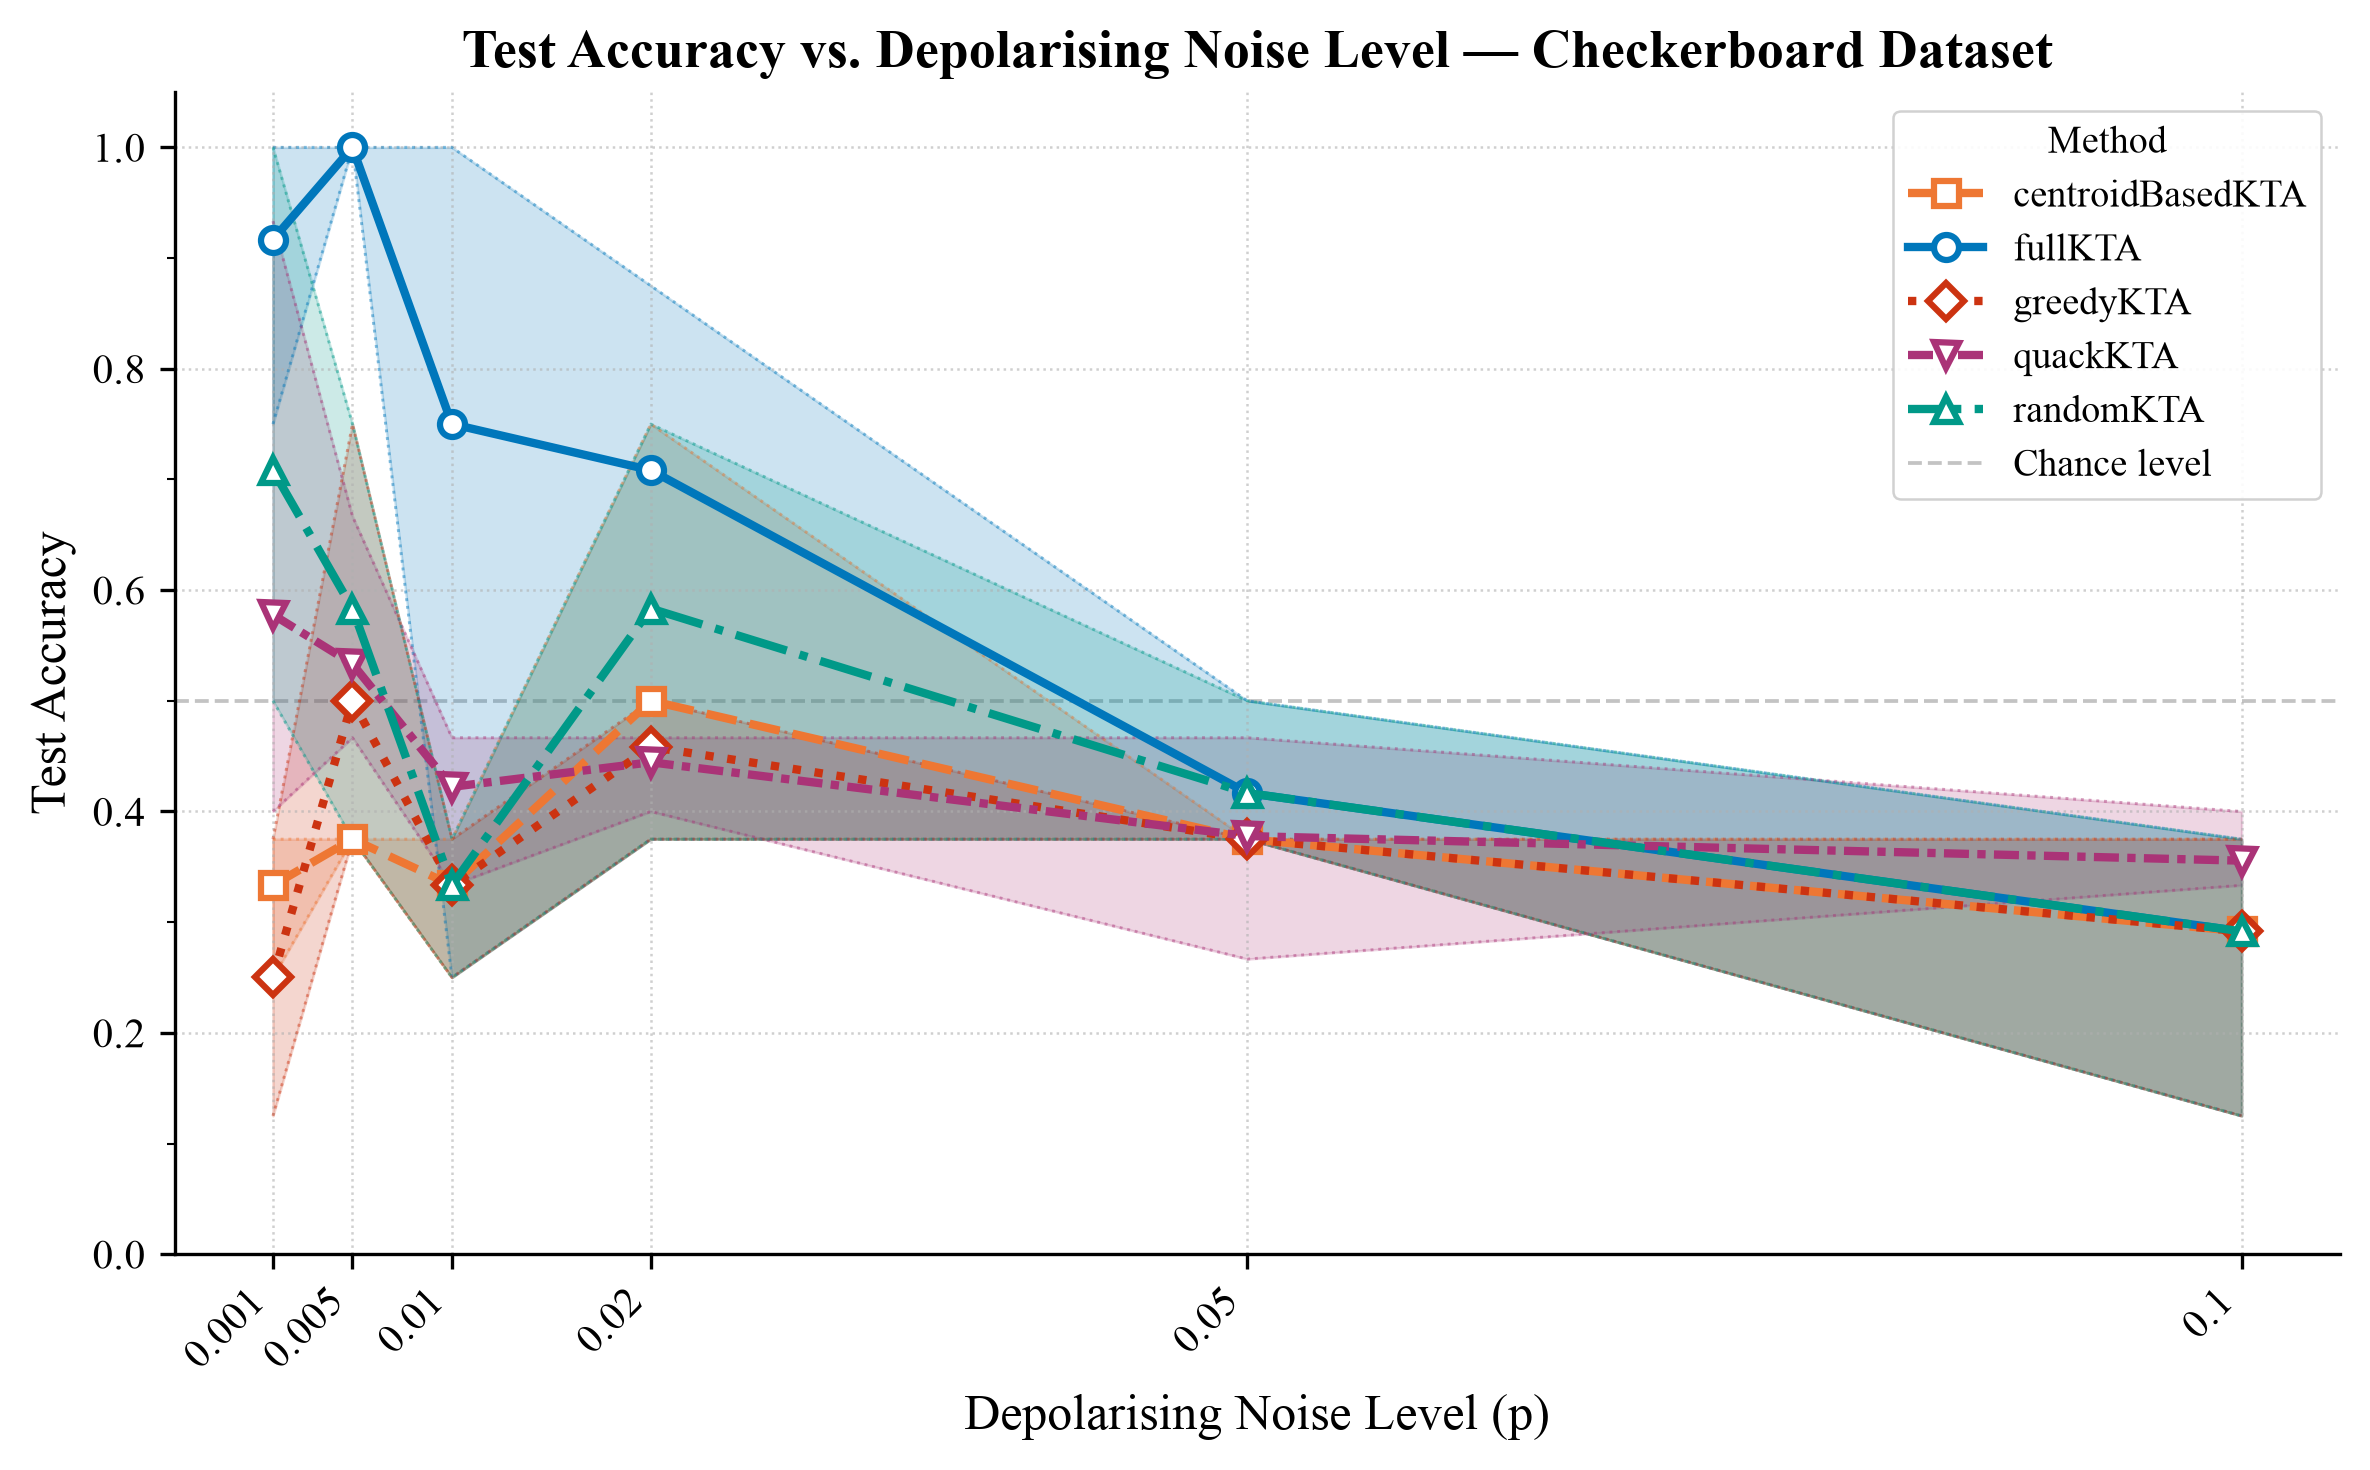

Saved: accuracy_vs_noise.png / accuracy_vs_noise.pdf


In [ ]:
summary = plot_accuracy_vs_noise(
    accuracy_results,
    dataset_name='Checkerboard Dataset',
)